# Image Annotation for Image Recognition and Segmentation

This notebook prepares a sample of images for annotation in Label Studio and produces the labeled dataset used to train the image-type classifier and segmentation models in notebook 06.

Images are annotated with both a **type label** and a **brush mask** over the color region. The original design called for five label classes:

- `swatch` — flat color swatch, no packaging; background thresholding is sufficient for extraction
- `bullet` — classic lipstick tube with exposed bullet tip
- `liquid` — liquid lipstick, stain, or gloss with doe-foot wand
- `closed` — container is closed but has a **transparent window through which the color is visible**; a mask is drawn over that window
- `color_not_shown` — container is fully sealed with no color visible; extraction is not possible

Round 3 surfaced two packaging patterns that didn't fit any of these and were added as new classes:

- `pencil` — pen/crayon-style applicator (twist-up or felt-tip), distinct from a bullet's tube or a liquid's doe-foot wand
- `lips` — the image shows the product applied to a model's lips rather than the product, its container, or a swatch

Round 4 merged `color_not_shown` with a newly-discovered `multi_image` case (multiple products, a palette, or otherwise not a single product shot) into one trained class, `unclassifiable` — see the Round 4 section for why. The current taxonomy is `swatch`, `bullet`, `liquid`, `closed`, `pencil`, `lips`, `unclassifiable`.

**Why `closed` and `unclassifiable` are separate classes:** Both involve packaging without a clean single product region, but they are fundamentally different extraction cases. `closed` images have a recoverable color (visible through the container) and route to a dedicated segmenter. `unclassifiable` images have nothing usable to extract and must be explicitly declined; otherwise the pipeline would invent a color from a sealed container or the wrong region of a multi-product photo. A first iteration of the classifier used a single `other` label for `closed` and the (then-untrained) `color_not_shown`, which collapsed that distinction and caused `color_not_shown` images to be misrouted to a segmenter. Splitting them into two classes is the fix — `unclassifiable` keeps that split, it just absorbs a second dead-end case (`multi_image`) that has the same downstream treatment as `color_not_shown` did.

**Annotation rounds:**
- Round 1: 208 images annotated (222 sampled, 14 missing from disk). Only 6 `closed` images — too few to train on.
- Round 2 (active learning): Rather than annotating at random, the 6 confirmed `closed` images from Round 1 were used to identify their product lines (Chanel Le Rouge Duo, BareMinerals Gen Nude Matte, Juice Beauty Phytopigments, Revlon Ultra HD Lip Mousse). Other shades from those same lines were targeted for annotation: same product = same packaging = high-confidence `closed` candidates, without requiring visual inspection of every image. 40 images were sampled proportionally across the 4 lines and annotated, bringing `closed` to 34 labeled examples.
- Round 3 (general oversampling): 54 additional images sampled; 49 annotated (5 left incomplete in Label Studio and excluded here). Split `bullet` (25), `liquid` (12), `closed` (5), and two new classes — `pencil` (4) and `lips` (3) — that didn't fit the original taxonomy. Brings the combined set to 297 labeled images.
- Round 4 (`lips`/`color_not_shown` oversampling): 37 images sampled from products likely to be lip-oil/balm/palette/multi-product shots — the two thinnest classes at the time. Brought `lips` to 19 and `color_not_shown` to 13, and surfaced `multi_image` (10) as a new pattern, merged with `color_not_shown` into `unclassifiable` (23 total). Brings the combined set to 339 labeled images.

**Steps:**
1. Explore product name keywords to understand type distribution in the annotation sample
2. Copy the 208 annotation sample images to `data/img/annotation_sample/` for Label Studio
3. Launch Label Studio and annotate: see Annotation Guidelines in this notebook
4. Load annotations and export to `data/processed/annotations.csv`
5. Oversample `closed` containers via product-line matching and run a second annotation round
6. Classifier and segmentation training → notebook 06

**Inputs:** `data/processed/annotation_sample.csv`, `data/processed/products_with_images.csv`, `data/img/original_clean/`, `data/processed/annotations_label_studio.json`, `data/processed/annotations_label_studio_closed_addition.json`, `data/processed/project-4-at-2026-07-24-22-36-c698fb5f.json`, `data/processed/project-4-at-2026-08-22-04-31-5c3d7d2b.json`

**Outputs:** `data/img/annotation_sample/` (208 images), `data/img/annotation_sample_closed/` (40 images), `data/processed/annotations.csv`, `data/processed/annotations_r2.csv`, `data/processed/annotations_r3.csv`, `data/processed/annotations_combined.csv`

# Setup

In [1]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import glob
import hashlib

BASE   = os.path.abspath('../data')
CLEAN  = os.path.join(BASE, 'img', 'original_clean')
ANNOT  = os.path.join(BASE, 'img', 'annotation_sample')
DATA   = os.path.join(BASE, 'processed')

# Label Studio truncates long filenames and appends a random 7-char suffix on
# upload (Django storage collision-avoidance), so long product names come back
# unresolvable against the catalog (see "Missing from original_clean" below).
# Recover the real name by hashing the uploaded file (local Label Studio media
# root) against the annotation staging folders -- these hold the exact bytes
# copied for each round under their real, untruncated name, and are a much
# smaller/cleaner candidate pool than the full 9k-image catalog (which often
# has several same-prefix shade variants, and can drift from what was staged
# if original_clean/ is reprocessed later). Falls back to a catalog-wide
# prefix/hash match only if nothing in staging accounts for it.
LS_UPLOAD_ROOT = os.path.expanduser('~/Library/Application Support/label-studio/media/upload')
STAGING_DIRS = [
    ANNOT,
    os.path.join(BASE, 'img', 'annotation_sample_closed'),
    os.path.join(BASE, 'img', 'annotation_sample_pencil'),
    os.path.join(BASE, 'img', 'annotation_sample_lips_notshown'),
    os.path.join(BASE, 'img', 'annotation_sample_style'),
    os.path.join(BASE, 'img', 'annotation_sample_color_strat'),
]

def _file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

_clean_hash_cache = {}
def _clean_hash(name):
    if name not in _clean_hash_cache:
        _clean_hash_cache[name] = _file_hash(os.path.join(CLEAN, name))
    return _clean_hash_cache[name]

_staging_index_cache = None
def _staging_index():
    global _staging_index_cache
    if _staging_index_cache is None:
        index = {}
        for d in STAGING_DIRS:
            if not os.path.isdir(d):
                continue
            for name in os.listdir(d):
                p = os.path.join(d, name)
                if os.path.isfile(p):
                    index.setdefault(_file_hash(p), set()).add(name)
        _staging_index_cache = index
    return _staging_index_cache

def resolve_truncated_name(img_name):
    """Map a possibly-truncated Label Studio filename back to its catalog name.
    Returns (resolved_name_or_None, reason)."""
    if os.path.exists(os.path.join(CLEAN, img_name)):
        return img_name, 'exact'

    upload_matches = glob.glob(os.path.join(LS_UPLOAD_ROOT, '*', f'*-{img_name}'))
    target_hash = _file_hash(upload_matches[0]) if upload_matches else None

    if target_hash is not None:
        staged = {n for n in _staging_index().get(target_hash, set())
                  if os.path.exists(os.path.join(CLEAN, n))}
        if len(staged) == 1:
            return next(iter(staged)), 'staging-hash-match'
        if len(staged) > 1:
            return None, f'ambiguous ({len(staged)} staged images share this exact photo)'

    # nothing usable in staging -- fall back to a catalog-wide prefix match
    stem, ext = os.path.splitext(img_name)
    prefix = stem.rsplit('_', 1)[0] if '_' in stem else stem
    candidates = [f for f in os.listdir(CLEAN) if f.startswith(prefix) and f.endswith(ext)]
    if len(candidates) == 1:
        return candidates[0], 'unique-prefix'
    if not candidates:
        return None, 'no-candidates'
    if target_hash is None:
        return None, 'no-upload-file'
    hash_matches = [c for c in candidates if _clean_hash(c) == target_hash]
    if len(hash_matches) == 1:
        return hash_matches[0], 'hash-match'
    if len(hash_matches) > 1:
        return None, f'ambiguous ({len(hash_matches)} catalog rows share this exact image)'
    return None, 'hash-mismatch'


# Exploring Product Types in the Annotation Sample

Product names in the metadata contain keywords that hint at visual format: "liquid", "stain", "velvet", etc. signal a wand/tube presentation rather than a classic bullet. This is not a ground truth label, but it gives a useful prior for understanding what annotators will encounter.

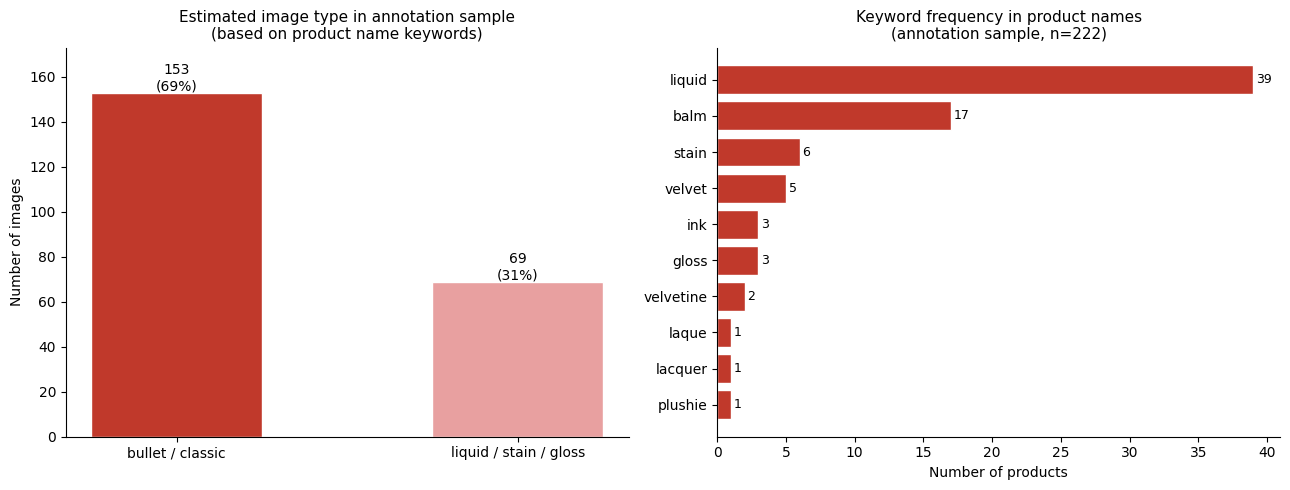


Total in sample: 222
product_type
bullet / classic          153
liquid / stain / gloss     69


In [2]:
sample   = pd.read_csv(f'{DATA}/annotation_sample.csv')
products = pd.read_csv(f'{DATA}/products_with_images.csv')
df       = sample.merge(products[['id', 'product']], on='id', how='left')

LIQUID_KEYWORDS = ['liquid', 'velvet', 'velvetine', 'plushie', 'fluid',
                   'stain', 'lacquer', 'laque', 'gloss', 'balm', 'ink', 'laquer']

def keyword_type(product_name):
    name = str(product_name).lower()
    return 'liquid / stain / gloss' if any(k in name for k in LIQUID_KEYWORDS) else 'bullet / classic'

df['product_type'] = df['product'].apply(keyword_type)

# --- figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: high-level split
counts = df['product_type'].value_counts()
colors = ['#c0392b', '#e8a0a0']
ax1.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
ax1.set_title('Estimated image type in annotation sample\n(based on product name keywords)', fontsize=11)
ax1.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax1.text(i, val + 1, f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=10)
ax1.set_ylim(0, counts.max() + 20)
ax1.spines[['top', 'right']].set_visible(False)

# Right: individual keyword frequency
keyword_counts = {}
for kw in LIQUID_KEYWORDS:
    n = df['product'].str.lower().str.contains(kw, na=False).sum()
    if n > 0:
        keyword_counts[kw] = n

kw_series = pd.Series(keyword_counts).sort_values()
ax2.barh(kw_series.index, kw_series.values, color='#c0392b', edgecolor='white')
ax2.set_title('Keyword frequency in product names\n(annotation sample, n=222)', fontsize=11)
ax2.set_xlabel('Number of products')
for i, val in enumerate(kw_series.values):
    ax2.text(val + 0.2, i, str(val), va='center', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA}/../img/product_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal in sample: {len(df)}')
print(df['product_type'].value_counts().to_string())

# Copy Annotation Sample to Label Studio Folder

The 222 images from `annotation_sample.csv` are copied from `original_clean/` (all `.jpg`) into `data/img/annotation_sample/`. Point Label Studio at this folder: it contains only the images that need to be labeled.

In [3]:
os.makedirs(ANNOT, exist_ok=True)

copied, skipped, missing = 0, 0, []

for img_name in sample.img_name:
    stem = os.path.splitext(img_name)[0]
    src  = os.path.join(CLEAN, stem + '.jpg')
    dst  = os.path.join(ANNOT, stem + '.jpg')

    if os.path.exists(dst):
        skipped += 1
        continue
    if not os.path.exists(src):
        missing.append(img_name)
        continue
    shutil.copy2(src, dst)
    copied += 1

print(f'Copied:  {copied}')
print(f'Skipped (already exists): {skipped}')
print(f'Missing from original_clean: {len(missing)}')
if missing:
    for name in missing:
        print(f'  {name}')

Copied:  30
Skipped (already exists): 178
Missing from original_clean: 14
  lipstick__bodyography__lipstick__opulent_red.jpg
  lipstick__pyt_beauty__double_duty_lipstick_gloss__deja_vu.jpg
  lipstick__kvd_beauty__everlasting_liquid_lipstick__echo.jpg
  lipstick__colourpop__ultra_blotted_lip__cypress_chill.jpg
  lipstick__becca_cosmetics__ultimate_lipstick_love__taupe.jpg
  lipstick__jcat_beauty__flash_metal_metallic_matte_lip__earthbound_explorer.jpg
  lipstick__bossy_cosmetics__bullet_lipstick__experienced.png
  lipstick__bossy_cosmetics__bullet_lipstick__graceful.jpg
  lipstick__lime_crime__matte_velvetine_lipstick__marshmallow.jpg
  lipstick__nyx_professional_makeup__dazed_diffused_blurring_lip_stick__roller_disco.jpg
  lipstick__milani__amore_satin_matte_lip_creme__violet_villain.jpg
  lipstick__lime_crime__metallic_velvetine_lipstick__eclipse.jpg
  lipstick__ulta__sheer_lipstick__red_raven.jpg
  lipstick__dose_of_colors__liquid_matte_lipstick__kiss_of_fire.jpg


14 of the 222 sampled images are missing from `original_clean/` because they were excluded by notebook 1B: 12 are transparent placeholder images (same 40KB file served by retailer pages for out-of-stock products) and 2 are corrupted files PIL cannot open. The annotation sample is therefore **208 images**. 

# Label Studio

Install and launch Label Studio. Point the image folder at `data/img/annotation_sample/`: 208 images, all `.jpg`.

Each image is annotated with a brush label: classify the image into one of the five categories and mask the area that shows the color. See **Annotation Guidelines** below for the full label schema and decision rules.

## Annotation Guidelines

Each image receives **one label** and a **brush mask over the area that shows the color**.

---

### Labels and masking rules

**`swatch`**: A flat color swatch with no packaging.
- Use only when the image contains *exclusively* a swatch (or swatches). If a bullet or liquid product appears alongside a swatch, label the image as `bullet` or `liquid` instead.
- Mask the swatch area.
- *Edge case:* An image contained two swatches of the same shade: one matte finish, one glossy. Both swatches were masked and the image was labeled `swatch` (two regions, same label).

**`bullet`**: Classic lipstick in a tube with the bullet tip visible.
- Mask the exposed bullet tip, where the color is concentrated.
- If a swatch also appears in the image, still label `bullet` and mask the bullet tip (not the swatch).

**`liquid`**: Liquid lipstick, lip stain, lacquer, or gloss (doe-foot wand or squeeze tube).
- Mask the wand tip or the product as shown.
- If a swatch also appears in the image, still label `liquid` and mask the liquid product (not the swatch).

**`closed`**: Container is closed but has a transparent window through which the color is visible.
- Mask the transparent color-showing area (typically a rectangle on the side of the container).

**`color_not_shown`**: Container is fully closed with no color visible at all (e.g., a lip balm in an opaque tube).
- Mask the entire container.
- This label is a fallback for images where color extraction is not possible from the image alone.

---

### Priority rule

When a product image contains **both a swatch and the product**, classify by the **product type** (`bullet` or `liquid`), not `swatch`. The `swatch`-only label is reserved for images where a swatch is the sole visual element.

--- 

### Learning

Mask annotation was performed on all three product types. In hindsight, swatches did not require manual segmentation masks: their simple white/black backgrounds allow reliable color extraction via background thresholding without a learned segmentation model. Future annotation rounds will focus mask effort exclusively on bullet and liquid lipstick.

## Run Label Studio

Install and launch it from a terminal, not a notebook cell — running the
server inline (`!label-studio start`) captures its Django request log as
cell output, and every run pollutes the notebook's git diff with thousands
of lines of server log.

```bash
python launch_label_studio.py
```

`launch_label_studio.py` lives at the repo root and is gitignored (personal
launcher, machine-specific paths) — it just runs `label-studio start`.

# Load Annotations

In [6]:
import json

with open(f'{DATA}/annotations_label_studio.json') as f:
    raw = json.load(f)

records = []
for task in raw:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    # strip the upload hash prefix (e.g. "a8d18c1f-lipstick__...")
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    # brush labels export: label is in value['brushlabels'][0]
    label = result[0]['value']['brushlabels'][0]
    records.append({'img_name': img_name, 'label': label})

annotations = pd.DataFrame(records)
annotations.to_csv(f'{DATA}/annotations.csv', index=False)

print(f'Saved {len(annotations)} annotations to data/processed/annotations.csv')
print(annotations['label'].value_counts().to_string())

Saved 208 annotations to data/processed/annotations.csv
label
swatch             96
bullet             61
liquid             44
closed              6
color_not_shown     1


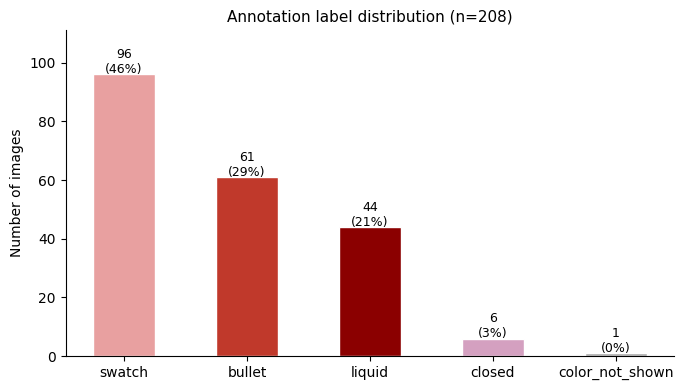

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = annotations['label'].value_counts()
colors_map = {'swatch': '#e8a0a0', 'bullet': '#c0392b', 'liquid': '#8b0000',
              'closed': '#d4a0c0', 'color_not_shown': '#aaa'}
bar_colors = [colors_map.get(l, '#999') for l in counts.index]

ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
ax.set_title('Annotation label distribution (n=208)', fontsize=11)
ax.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.5, f'{val}\n({val/len(annotations)*100:.0f}%)', ha='center', fontsize=9)
ax.set_ylim(0, counts.max() + 15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Updated Annotations: Combined Label Distribution

After annotating the 40-image closed-container batch in Label Studio, the full project was re-exported to `annotations_label_studio_closed_addition.json`. This export contains all 248 annotated images (208 original + 40 new).

The cells below load these annotations and save them to `annotations_r2.csv` for comparison. Round 3, below, supersedes this file as the input to notebook 06.

In [8]:
import json

with open(f'{DATA}/annotations_label_studio_closed_addition.json') as f:
    raw_r2 = json.load(f)

records_r2 = []
for task in raw_r2:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    label = result[0]['value']['brushlabels'][0]
    records_r2.append({'img_name': img_name, 'label': label})

annotations_r2 = pd.DataFrame(records_r2)
annotations_r2.to_csv(f'{DATA}/annotations_r2.csv', index=False)

print(f'Saved {len(annotations_r2)} annotations to data/processed/annotations_r2.csv')
print(annotations_r2['label'].value_counts().to_string())

Saved 248 annotations to data/processed/annotations_r2.csv
label
swatch             105
bullet              61
liquid              47
closed              34
color_not_shown      1


# Round 3: General Oversampling and New Classes

A further 54 images were sampled and annotated in Label Studio, re-exported as `project-4-at-2026-07-24-22-36-c698fb5f.json`. This export is the full, cumulative project (302 tasks) and supersedes both prior exports — it doesn't need to be merged with `annotations.csv` or `annotations_r2.csv`. 49 of the 54 new images were annotated before export; 5 were left incomplete and are dropped here the same way as any other task with an empty `result`.

Two packaging patterns turned up in this round that don't fit the original four classes and were added as new classes rather than folded into `bullet`/`liquid`:
- `pencil` (4 images) — pen/crayon-style applicator
- `lips` (3 images) — the product shown on a model's lips, not on packaging or a swatch

The rest of the new images split `bullet` (25), `liquid` (12), `closed` (5).

This is the final, cumulative export — the cell below saves it to `annotations_combined.csv`, the file notebook 06 trains on.

In [9]:
import json

with open(f'{DATA}/project-4-at-2026-07-24-22-36-c698fb5f.json') as f:
    raw_r3 = json.load(f)

records_r3 = []
for task in raw_r3:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    label = result[0]['value']['brushlabels'][0]
    records_r3.append({'img_name': img_name, 'label': label})

annotations_combined = pd.DataFrame(records_r3)
annotations_combined.to_csv(f'{DATA}/annotations_combined.csv', index=False)
annotations_combined.to_csv(f'{DATA}/annotations_r3.csv', index=False)  # frozen snapshot for later comparison

print(f'Saved {len(annotations_combined)} annotations to data/processed/annotations_combined.csv')
print(annotations_combined['label'].value_counts().to_string())

Saved 297 annotations to data/processed/annotations_combined.csv
label
swatch             105
bullet              83
liquid              59
closed              39
pencil               7
lips                 3
color_not_shown      1


# Round 4: Lips/Color-Not-Shown Oversampling and the `unclassifiable` Class

Following Round 3, `lips` and `color_not_shown` were the two thinnest classes (3 and 1 examples). 37 shades were sampled from products likely to hit these cases -- lip oils/balms/palettes/multi-product listings -- and annotated in Label Studio, re-exported as `project-4-at-2026-08-22-04-31-5c3d7d2b.json`. This is again the full cumulative project (339 tasks, no gaps) and supersedes the Round 3 export.

Annotating this batch surfaced a class the taxonomy didn't have yet: `multi_image` (10 images, spelled `multi_impage` in the raw export -- a Label Studio label-config typo, corrected on load below) -- photos showing multiple products, a palette, or something other than a single product shot, where there's no one region to extract a color from. That's a different-looking case from `color_not_shown` (13 images: a single, fully sealed product with nothing visible) but both lead to the same downstream treatment -- no color extraction -- so they're merged here into one label, `unclassifiable`, rather than kept as two classes with identical treatment. (This is not the same mistake as the earlier `closed` + `color_not_shown` -> `other` collapse: that merged a *routable* class with a dead-end one and caused misrouting. Here both source labels are dead ends, so nothing is lost by merging them.)

Unlike the original design (`color_not_shown` as a confidence-threshold fallback, never trained on), `unclassifiable` is trained as a real class in notebook 06. The fallback approach depends on the classifier being *unconfident* about images it's never seen, which isn't reliable -- a multi-product photo can easily contain something that looks enough like a `bullet` to get a confident, wrong prediction. With 23 real examples now labeled, training the model to recognize the pattern directly should catch more of these than hoping for low confidence.

- `lips`: 3 -> 19
- `pencil`: 7 -> 9 (2 incidental additions from this batch)
- `unclassifiable` (new): 23 (`color_not_shown` 13 + `multi_impage` 10)

This is now the final, cumulative export -- the cell below saves it to `annotations_combined.csv`.

In [ ]:
import json

LABEL_REMAP_R4 = {'multi_impage': 'unclassifiable', 'color_not_shown': 'unclassifiable'}

with open(f'{DATA}/project-4-at-2026-08-22-04-31-5c3d7d2b.json') as f:
    raw_r4 = json.load(f)

records_r4 = []
for task in raw_r4:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    label = result[0]['value']['brushlabels'][0]
    label = LABEL_REMAP_R4.get(label, label)
    records_r4.append({'img_name': img_name, 'label': label})

annotations_combined = pd.DataFrame(records_r4)
annotations_combined.to_csv(f'{DATA}/annotations_combined.csv', index=False)
annotations_combined.to_csv(f'{DATA}/annotations_r4.csv', index=False)  # frozen snapshot for later comparison

print(f'Saved {len(annotations_combined)} annotations to data/processed/annotations_combined.csv')
print(annotations_combined['label'].value_counts().to_string())

Saved 339 annotations to data/processed/annotations_combined.csv
label
swatch            106
bullet             84
liquid             59
closed             39
unclassifiable     23
lips               19
pencil              9


# Round 5: Pencil/Crayon Keyword Oversampling

Notebook 03's Strategy 4 searched `products_with_images.csv` for "pencil"/"crayon" in the product name and sampled 40 unannotated candidates across 21 product lines, staged in `annotation_sample_pencil/`. Annotated in Label Studio, re-exported as `project-4-at-2026-08-22-23-28-2ae685b5.json`. This is again the full cumulative project (379 tasks, no gaps) and supersedes the Round 4 export.

Keyword matching on product name turned out to be a weaker proxy for packaging type than hoped: of the 40 new images, only **18** were actually `pencil` packaging -- **17** turned out to be swatch photos of a pencil-formula product, and **5** were multi-product shots (`multi_impage` -> `unclassifiable`). A "pencil" or "crayon" product name doesn't guarantee the photo shows the pencil itself.

One existing annotation was also corrected in this export: task 332 (`mineral_fusion__sheer_moisture_lip_tint__shimmer.jpg`) changed from `lips` to `pencil`.

- `pencil`: 9 -> 28 (18 from this batch + the task-332 correction)
- `swatch`: 106 -> 123
- `unclassifiable`: 23 -> 28 (+5 `multi_impage`)
- `lips`: 19 -> 18 (-1, the task-332 correction)

This is now the final, cumulative export -- the cell below saves it to `annotations_combined.csv`.

In [ ]:
import json

LABEL_REMAP_R5 = {'multi_impage': 'unclassifiable', 'color_not_shown': 'unclassifiable'}

with open(f'{DATA}/project-4-at-2026-08-22-23-28-2ae685b5.json') as f:
    raw_r5 = json.load(f)

records_r5 = []
unresolved_r5 = []
for task in raw_r5:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    label = result[0]['value']['brushlabels'][0]
    label = LABEL_REMAP_R5.get(label, label)

    resolved_name, reason = resolve_truncated_name(img_name)
    if resolved_name is not None:
        img_name = resolved_name
    else:
        unresolved_r5.append((img_name, reason))
    records_r5.append({'img_name': img_name, 'label': label})

annotations_combined = pd.DataFrame(records_r5)
annotations_combined.to_csv(f'{DATA}/annotations_combined.csv', index=False)

print(f'Saved {len(annotations_combined)} annotations to data/processed/annotations_combined.csv')
print(annotations_combined['label'].value_counts().to_string())
if unresolved_r5:
    print(f'\n{len(unresolved_r5)} names still unresolved against the catalog (kept as recorded, will not copy/merge):')
    for name, reason in unresolved_r5:
        print(f'  {name}: {reason}')


Saved 379 annotations to data/processed/annotations_combined.csv
label
swatch            123
bullet             84
liquid             59
closed             39
pencil             28
unclassifiable     28
lips               18

4 names still unresolved against the catalog (kept as recorded, will not copy/merge):
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_fgYRKxv.jpg: ambiguous (4 staged images share this exact photo)
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_CxtbZqH.jpg: ambiguous (4 staged images share this exact photo)
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_x1FNXTo.jpg: ambiguous (4 staged images share this exact photo)
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_h6Uf7Zn.jpg: ambiguous (4 staged images share this exact photo)


# Round 6: Annotation Correction Pass (2026-09-18)

On 2026-09-17/18 a handful of errors found in earlier annotations were
corrected directly in Label Studio (same 868 tasks throughout, no images
added or removed -- this is a correction pass, not a new oversampling round).
Re-exported as `project-4-at-2026-09-18-21-20-25213916.json`; the
2026-09-17 export is superseded and not used here.

24 pre-`2026-09-01` (training-round) tasks differ from the previous export,
but only **3 are actual label changes** here (a 4th, the Milani `v_cute`
crayon, was already hand-corrected on 2026-09-12 -- see CLAUDE.md) -- the
rest are brush-mask-only corrections, which don't touch
`annotations_combined.csv` and are instead picked up when notebook 06_a
re-decodes masks from this same export. (27 more changed tasks are
post-cutoff validation-worklist annotations, handled separately by notebook
04_b.)

**Note on how this cell differs from Rounds 3-5:** those cells fully rebuild
`annotations_combined.csv` from their own frozen Label Studio export --
appropriate for a one-time historical replay, but destructive if the
notebook is ever re-executed top-to-bottom, since it would also erase the 13
rows added by hand after the 2026-09-12 active-learning cleanup (pool images
that were never Label Studio tasks) and revert the 4 L'Oréal `unclassifiable`
rows to their unresolvable truncated names (see CLAUDE.md's Label Studio
truncation note -- those 4 stay content-ambiguous and are skipped here too,
same as always; their label doesn't actually change). This cell instead
**merges** by `img_name` into the existing file, so it's safe to add without
disturbing that later, out-of-band history. **For the same reason, this
cell (and this whole notebook) should not be re-executed top-to-bottom** --
it was run once, standalone, against the then-current `annotations_combined.csv`;
the printed output below is that real run's output, not a notebook-wide
nbconvert execution.


In [ ]:
import json

LABEL_REMAP_R6 = {'multi_impage': 'unclassifiable', 'color_not_shown': 'unclassifiable'}
R6_CUTOFF = '2026-09-01'  # tasks created on/after this are validation-worklist annotations (see notebook 04_b), not training

with open(f'{DATA}/project-4-at-2026-09-18-21-20-25213916.json') as f:
    raw_r6 = json.load(f)

annotations_combined = pd.read_csv(f'{DATA}/annotations_combined.csv')
label_by_name = dict(zip(annotations_combined['img_name'], annotations_combined['label']))

updated, unresolved_r6, unmatched_r6 = [], [], []
for task in raw_r6:
    ann = task['annotations'][0]
    result = ann['result']
    if not result or ann.get('created_at', '') >= R6_CUTOFF:
        continue  # incomplete, or a validation-worklist annotation (see notebook 04_b)

    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name
    raw_label = result[0]['value']['brushlabels'][0]
    label = LABEL_REMAP_R6.get(raw_label, raw_label)

    if img_name not in label_by_name:
        resolved_name, reason = resolve_truncated_name(img_name)
        if resolved_name is None:
            unresolved_r6.append((img_name, reason))
            continue
        img_name = resolved_name

    if img_name not in label_by_name:
        unmatched_r6.append(img_name)  # resolved, but not part of the existing training set
        continue

    if label_by_name[img_name] != label:
        updated.append((img_name, label_by_name[img_name], label))
        label_by_name[img_name] = label

annotations_combined['label'] = annotations_combined['img_name'].map(label_by_name)
annotations_combined.to_csv(f'{DATA}/annotations_combined.csv', index=False)

print(f'{len(updated)} label(s) corrected (of {len(annotations_combined)} total rows, unchanged):')
for name, old, new in updated:
    print(f'  {name}: {old} -> {new}')
if unresolved_r6:
    print(f'\n{len(unresolved_r6)} names unresolved against the catalog (skipped, label unchanged):')
    for name, reason in unresolved_r6:
        print(f'  {name}: {reason}')
if unmatched_r6:
    print(f'\n{len(unmatched_r6)} resolved names not found in the existing training set (skipped):')
    for name in unmatched_r6:
        print(f'  {name}')
print()
print(annotations_combined['label'].value_counts().to_string())


3 label(s) corrected (of 392 total rows, unchanged):
  lipstick__covergirl__outlast_lipstain__05_all_star.jpg: bullet -> pencil
  lipstick__julep__its_balm_creme_full_coverage_lip_crayon__04_dusty_orchid_shimmer.jpg: bullet -> pencil
  lipstick__kylie_cosmetics__matte_lip_kit__no_sleep.jpg: bullet -> unclassifiable

4 names unresolved against the catalog (skipped, label unchanged):
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_fgYRKxv.jpg: ambiguous (4 staged images share this exact photo)
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_CxtbZqH.jpg: ambiguous (4 staged images share this exact photo)
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_x1FNXTo.jpg: ambiguous (4 staged images share this exact photo)
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_h6Uf7Zn.jpg: ambiguous (4 staged images share this exact photo)

label
swatch            127
bullet             80
liquid          

### Copy Newly Annotated Images to the Label Studio Folders

`annotation_sample/` and `annotation_sample_closed/` are the curated folders notebook 06 reads images from (see `IMG_DIRS`) -- they're meant to hold every image referenced in `annotations_combined.csv`, not the full 9k-image `original_clean/` universe. Rounds 3 and 4 both added images that were never copied there (Round 4's oversampling batch was staged in `annotation_sample_lips_notshown/` for review, not copied into the folder notebook 06 actually reads). The cell below copies anything referenced in the final combined annotations that isn't already present in `annotation_sample/` or `annotation_sample_closed/`.

In [ ]:
copied, skipped, missing = 0, 0, []
closed_dir = os.path.join(BASE, 'img', 'annotation_sample_closed')

os.makedirs(ANNOT, exist_ok=True)
for img_name in annotations_combined['img_name']:
    if os.path.exists(os.path.join(ANNOT, img_name)) or os.path.exists(os.path.join(closed_dir, img_name)):
        skipped += 1
        continue
    src = os.path.join(CLEAN, img_name)
    if not os.path.exists(src):
        missing.append(img_name)
        continue
    shutil.copy2(src, os.path.join(ANNOT, img_name))
    copied += 1

print(f'Copied:  {copied}')
print(f'Skipped (already present): {skipped}')
print(f'Missing from original_clean: {len(missing)}')
if missing:
    for name in missing:
        print(f'  {name}')

Copied:  1
Skipped (already present): 374
Missing from original_clean: 4
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_fgYRKxv.jpg
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_CxtbZqH.jpg
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_x1FNXTo.jpg
  lipstick__loreal__infallible_matte_lip_crayon_lasting_wear_smudge_resi_h6Uf7Zn.jpg


In [ ]:
annotations = pd.read_csv(f'{DATA}/annotations.csv')
annotations_r2 = pd.read_csv(f'{DATA}/annotations_r2.csv')
annotations_r3 = pd.read_csv(f'{DATA}/annotations_r3.csv')
annotations_r4 = pd.read_csv(f'{DATA}/annotations_r4.csv')
annotations_combined = pd.read_csv(f'{DATA}/annotations_combined.csv')

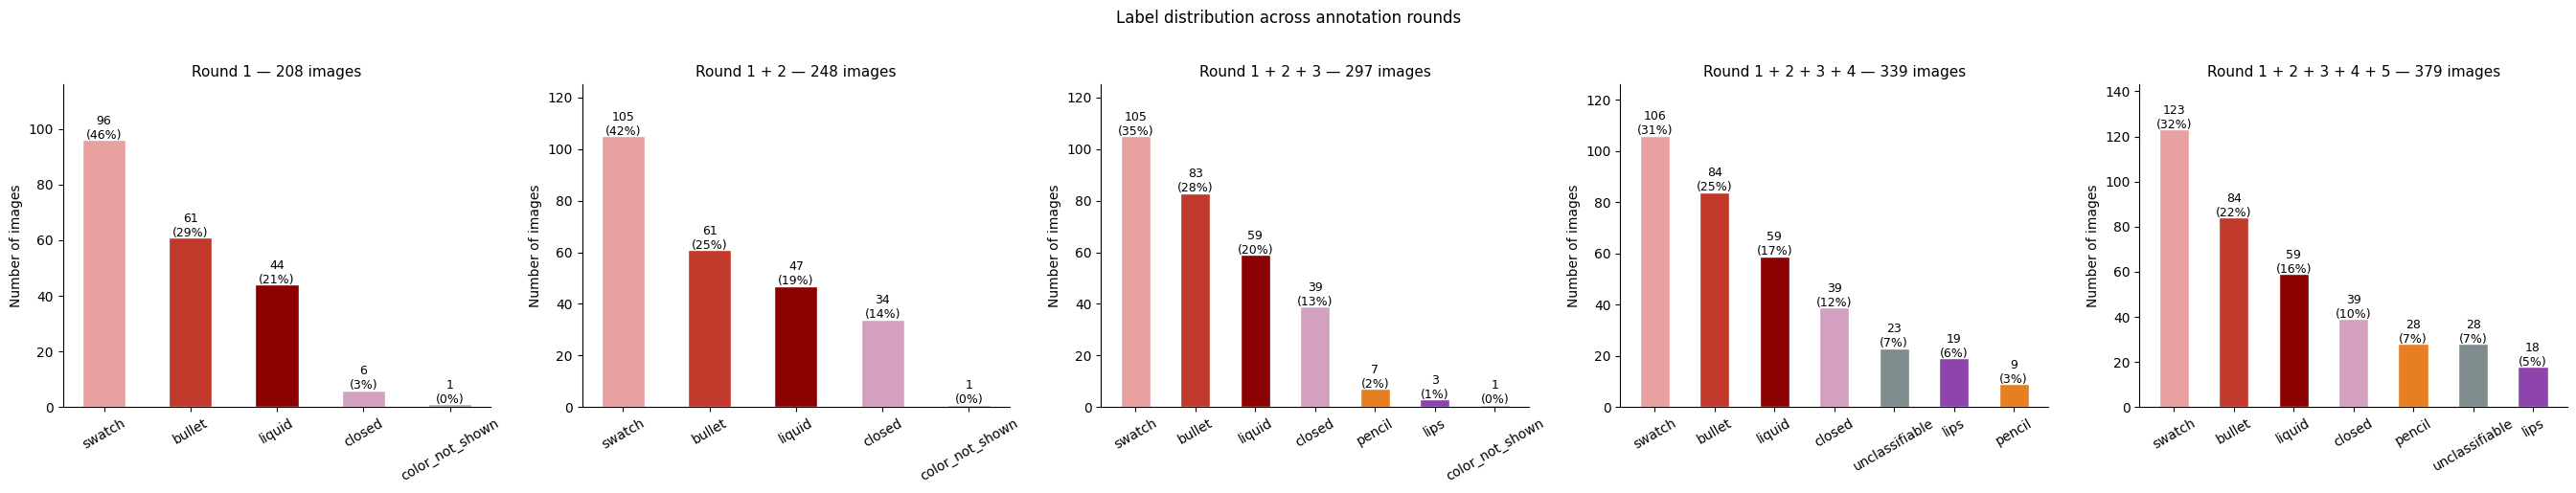

In [ ]:
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(27, 5))

colors_map = {'swatch': '#e8a0a0', 'bullet': '#c0392b', 'liquid': '#8b0000',
              'closed': '#d4a0c0', 'color_not_shown': '#aaa',
              'pencil': '#e67e22', 'lips': '#8e44ad', 'unclassifiable': '#7f8c8d'}

for ax, df, title in [
    (ax1, annotations,          'Round 1 — 208 images'),
    (ax2, annotations_r2,       'Round 1 + 2 — 248 images'),
    (ax3, annotations_r3,       'Round 1 + 2 + 3 — 297 images'),
    (ax4, annotations_r4,       'Round 1 + 2 + 3 + 4 — 339 images'),
    (ax5, annotations_combined, 'Round 1 + 2 + 3 + 4 + 5 — 379 images'),
]:
    counts = df['label'].value_counts()
    bar_colors = [colors_map.get(l, '#999') for l in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Number of images')
    for i, (label, val) in enumerate(counts.items()):
        ax.text(i, val + 0.5, f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, counts.max() + 20)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Label distribution across annotation rounds', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution_combined.png', dpi=150, bbox_inches='tight')
plt.show()

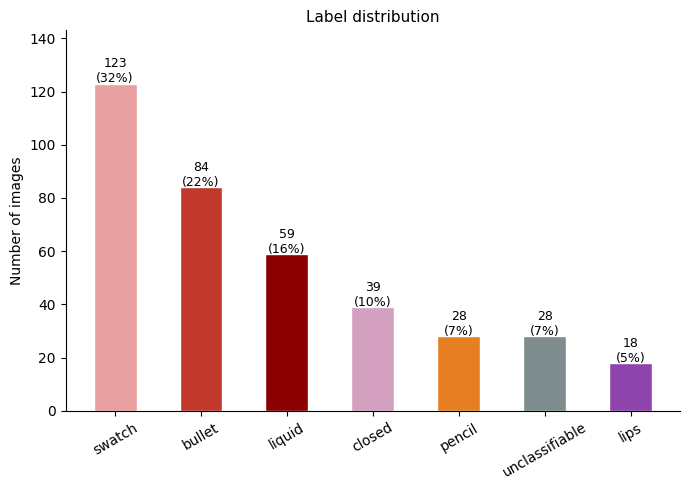

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = annotations_combined['label'].value_counts()
bar_colors = [colors_map.get(l, '#999') for l in counts.index]
ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
ax.set_title('Label distribution', fontsize=11)
ax.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.5, f'{val}\n({val/len(annotations_combined)*100:.0f}%)', ha='center', fontsize=9)
ax.set_ylim(0, counts.max() + 20)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()